# OpenMLS v4 statistics analysis

This notebook intentionally keeps the legacy `statistics_analysis_openmls_v3.ipynb` filename, but its contents now reflect the v4 OpenMLS benchmark state.

The notebook sources `statistics_analysis_openmls_v4.R`, reads all v4 `events.csv` files under `OpenMLS_containerized/benchmark_output`, and separates protocol-structural spans from broad OpenMLS API spans. The 3D surfaces use thin-plate spline GAMs, not multidimensional LOESS.

Scientific status:

- `update_path_compute_protocol_core` is the main protocol-structural span.
- `commit_create_protocol_*`, join, and application message protocol rows remain broad OpenMLS implementation spans unless a child span says otherwise.
- application-message plots are diagnostic until generation, padding, AAD, and secret-tree counters are complete.
- CPU and L1D plots are resource diagnostics, not RFC complexity evidence.


In [1]:
source("statistics/statistics_analysis_openmls_v4.R")

options(repr.plot.width = 18, repr.plot.height = 8)
openmls_v4_df <- read_openmls_v4_raw()
summarise_openmls_v4_data(openmls_v4_df)


Loaded derived OpenMLS v4 data cache: OpenMLS_containerized/benchmark_output/.analysis_cache_v4/openmls_v4_raw_derived.rds



op,measurement_plane,span_kind,rows,runs,member_min,member_max,tree_height_min,tree_height_max,payload_min,payload_max,wall_ms_median,alloc_bytes_median,finite_l1d_hit_ratio
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
update_path_compute_protocol_core,NA,NA,2941,3,1,2048,4,11,NA,NA,24.1218750,1781453.0,0
commit_create_protocol_update,NA,NA,2124,3,10,2048,4,11,NA,NA,30.7284825,5057733.0,0
commit_create_protocol_add,NA,NA,791,3,1,2042,4,11,NA,NA,34.9426100,10445202.0,0
commit_create_protocol_remove,NA,NA,26,3,12,1882,7,11,NA,NA,26.4248380,2600028.5,0
self_update.proposal_apply,NA,NA,2124,3,10,2048,NA,NA,NA,NA,0.0127890,144.0,0
self_update.path_structure_build,NA,NA,2124,3,10,2048,4,11,NA,NA,0.1772830,129704.0,0
self_update.path_secret_derive,NA,NA,2124,3,10,2048,4,11,NA,NA,0.3182540,5820.0,0
self_update.path_hpke_encrypt,NA,NA,2124,3,10,2048,4,11,NA,NA,19.4683610,427902.0,0
self_update.tree_hash_recompute,NA,NA,2124,3,10,2048,4,11,NA,NA,1.8586020,481179.0,0


## Dataset and structural-counter checks

This prints the combined v4 schema summary, operation counts, UpdatePath counter consistency, and Welcome recipient summary. The most important sanity check is that UpdatePath node counts, filtered direct path length, path secret derivations, HPKE encrypt counts, and copath-resolution counts agree where expected.


In [2]:
audit_openmls_v4_data(openmls_v4_df)


# A tibble: 1 × 7
  files  rows schema_versions operations  runs measurement_planes span_kinds
  <int> <int> <chr>                <int> <int> <chr>              <chr>     
1     3 53239 11                      34     3 ""                 ""        
# A tibble: 34 × 5
   op                   measurement_plane span_kind profile_schema_version  rows
   <chr>                <chr>             <chr>                      <dbl> <int>
 1 application_message… NA                NA                            11  6372
 2 application_message… NA                NA                            11  6372
 3 application_message… NA                NA                            11  5136
 4 application_message… NA                NA                            11  5136
 5 update_path_compute… NA                NA                            11  2941
 6 commit_create_proto… NA                NA                            11  2124
 7 self_update.commit_… NA                NA                            11  2124
 8 

## UpdatePath protocol-structural span

This is the closest current span to RFC-relevant UpdatePath behavior. It is still structural work, not pure cryptographic primitive timing.


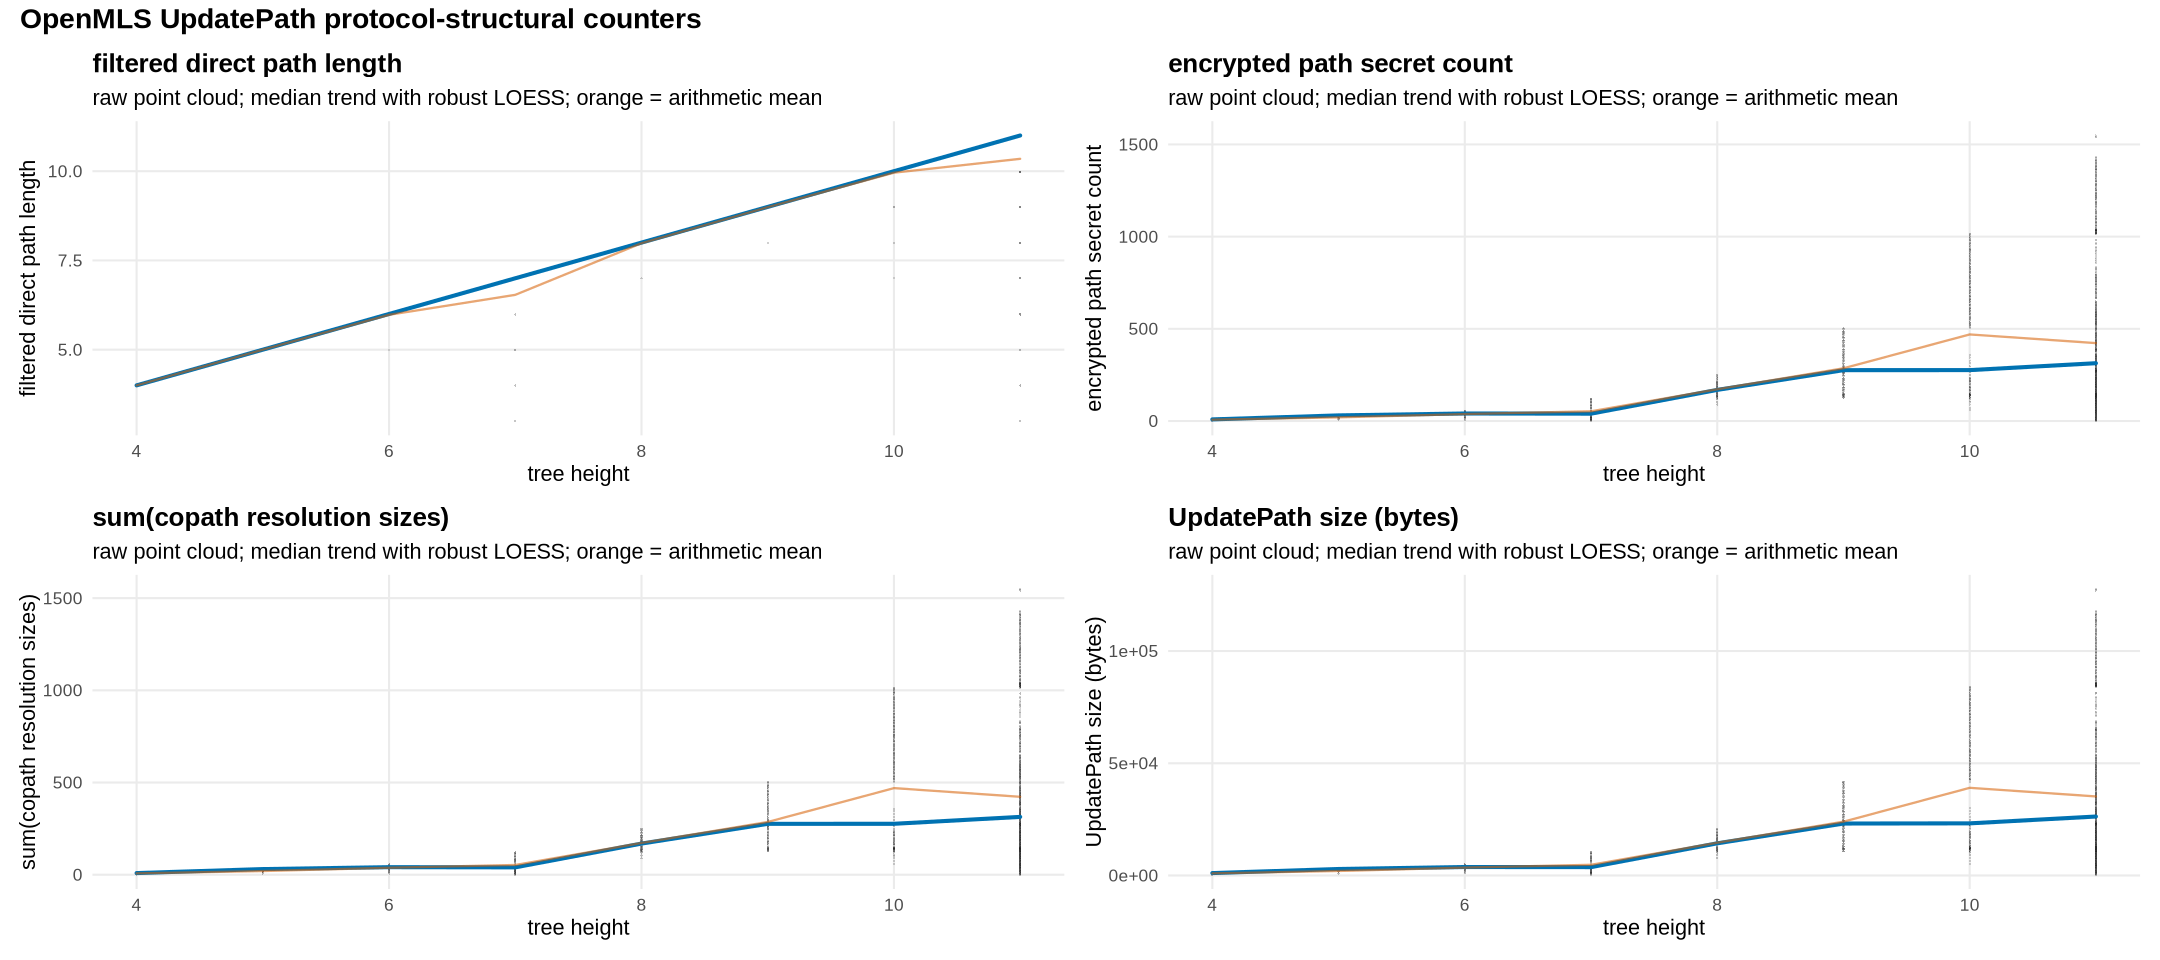

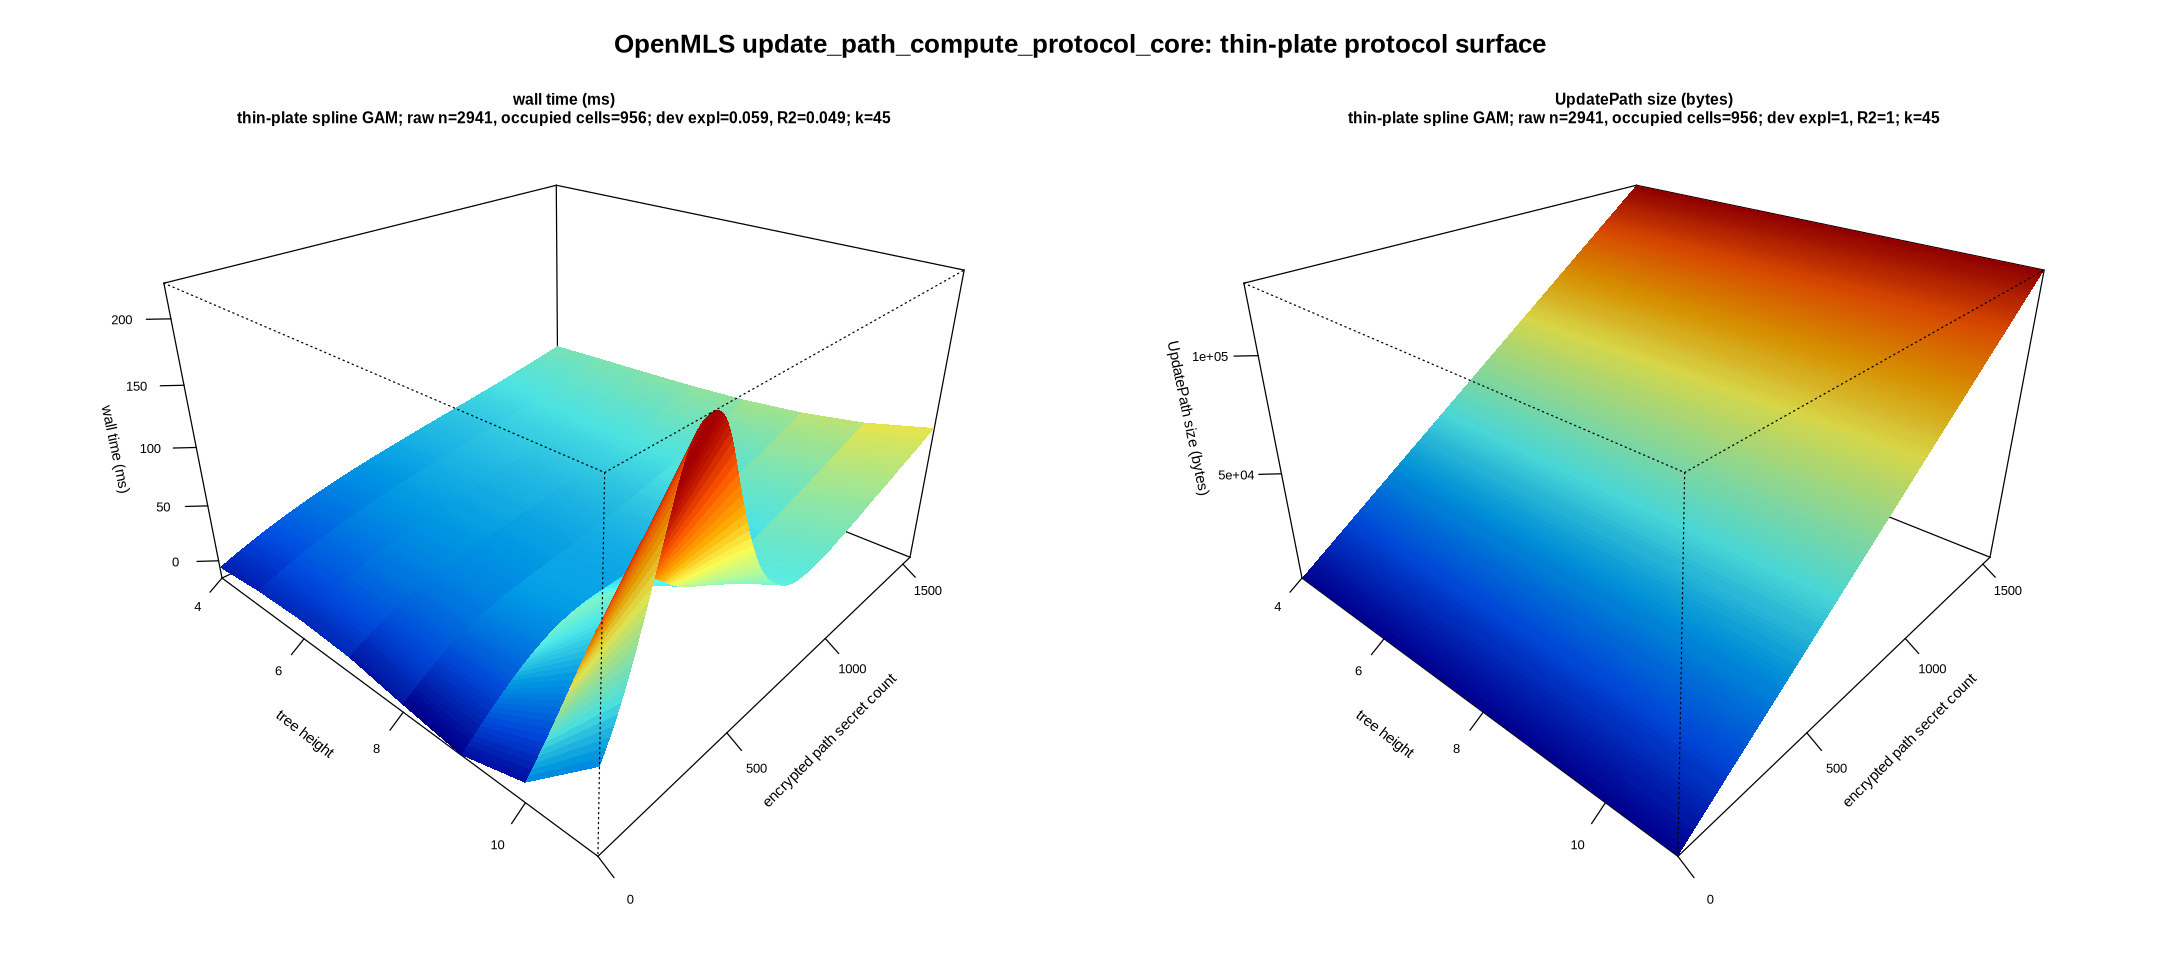

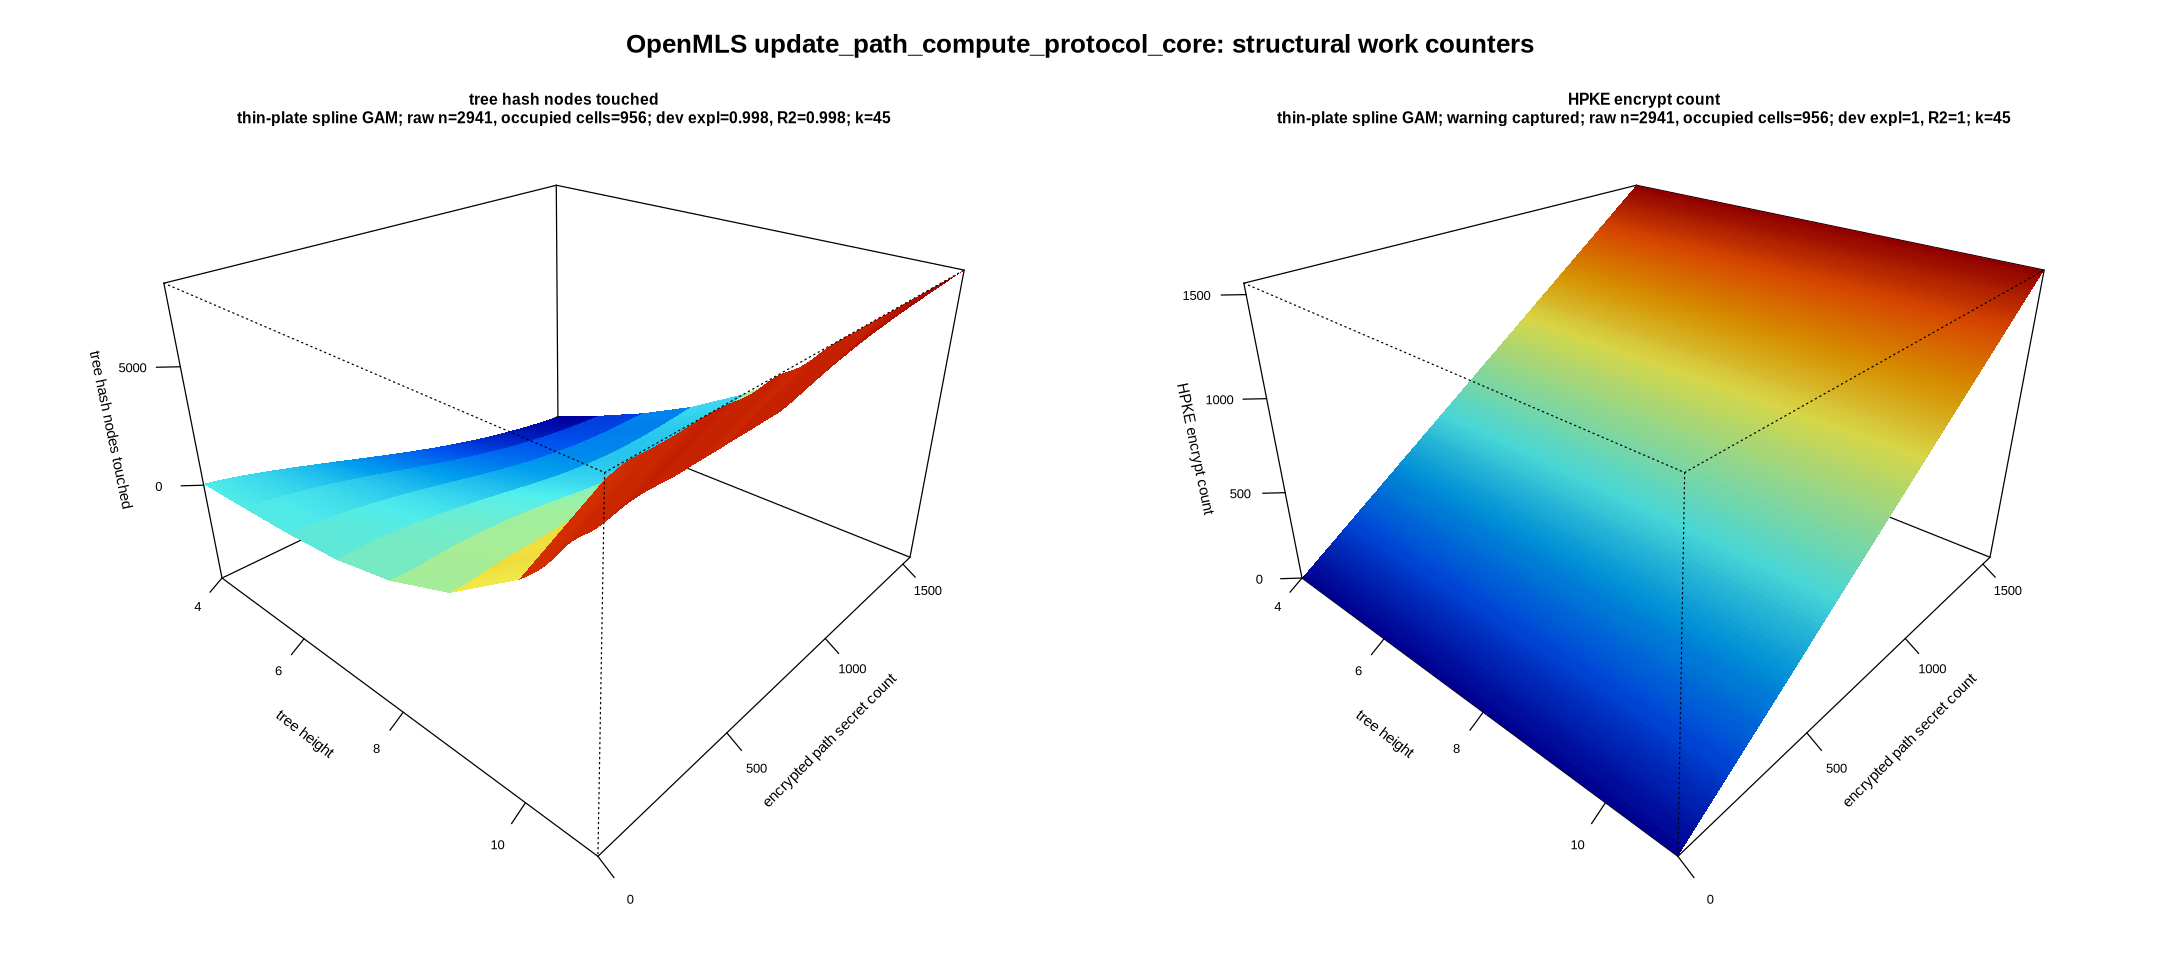

In [3]:
options(repr.plot.width = 18, repr.plot.height = 8)
plot_openmls_update_path_core(openmls_v4_df)


## Broad commit API spans

These remain OpenMLS implementation-level measurements. Use them to compare implementation cost against the protocol-structural child spans, not as pure RFC UpdatePath timings.


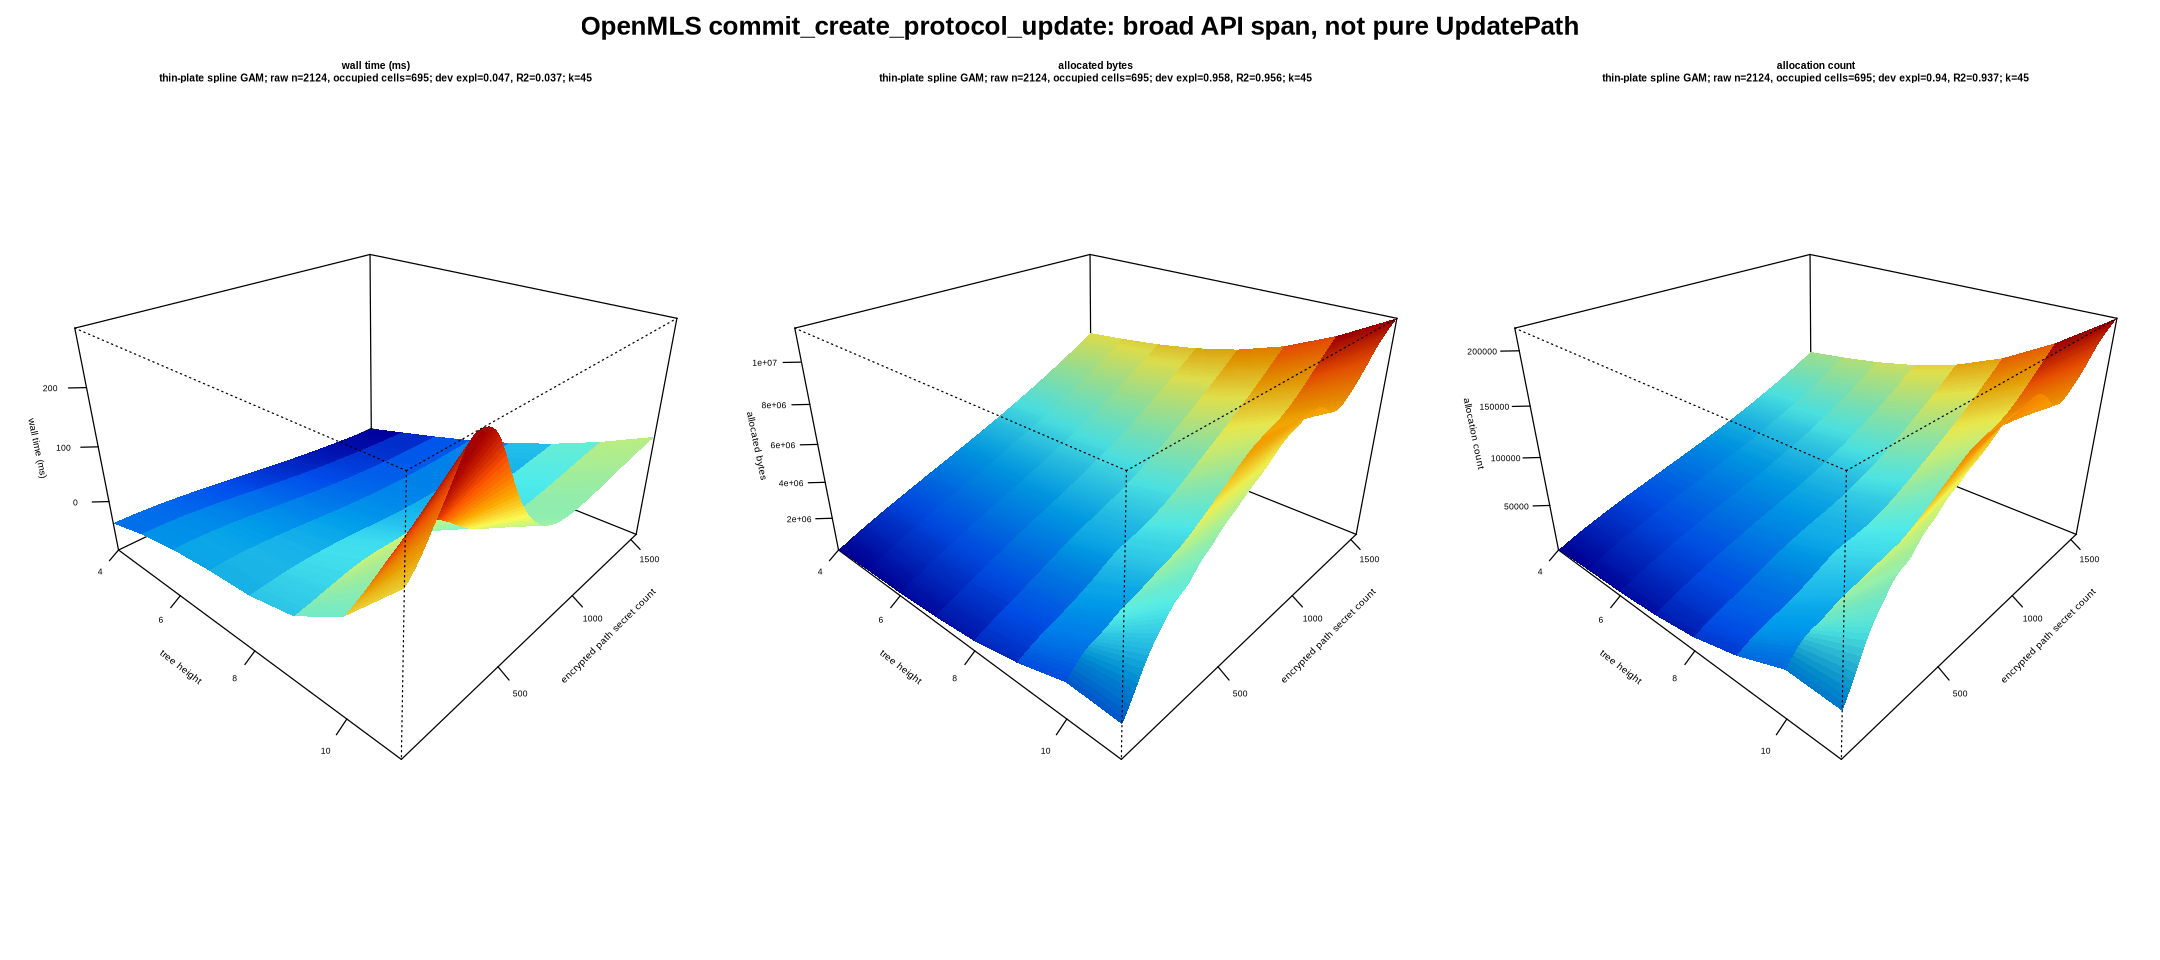

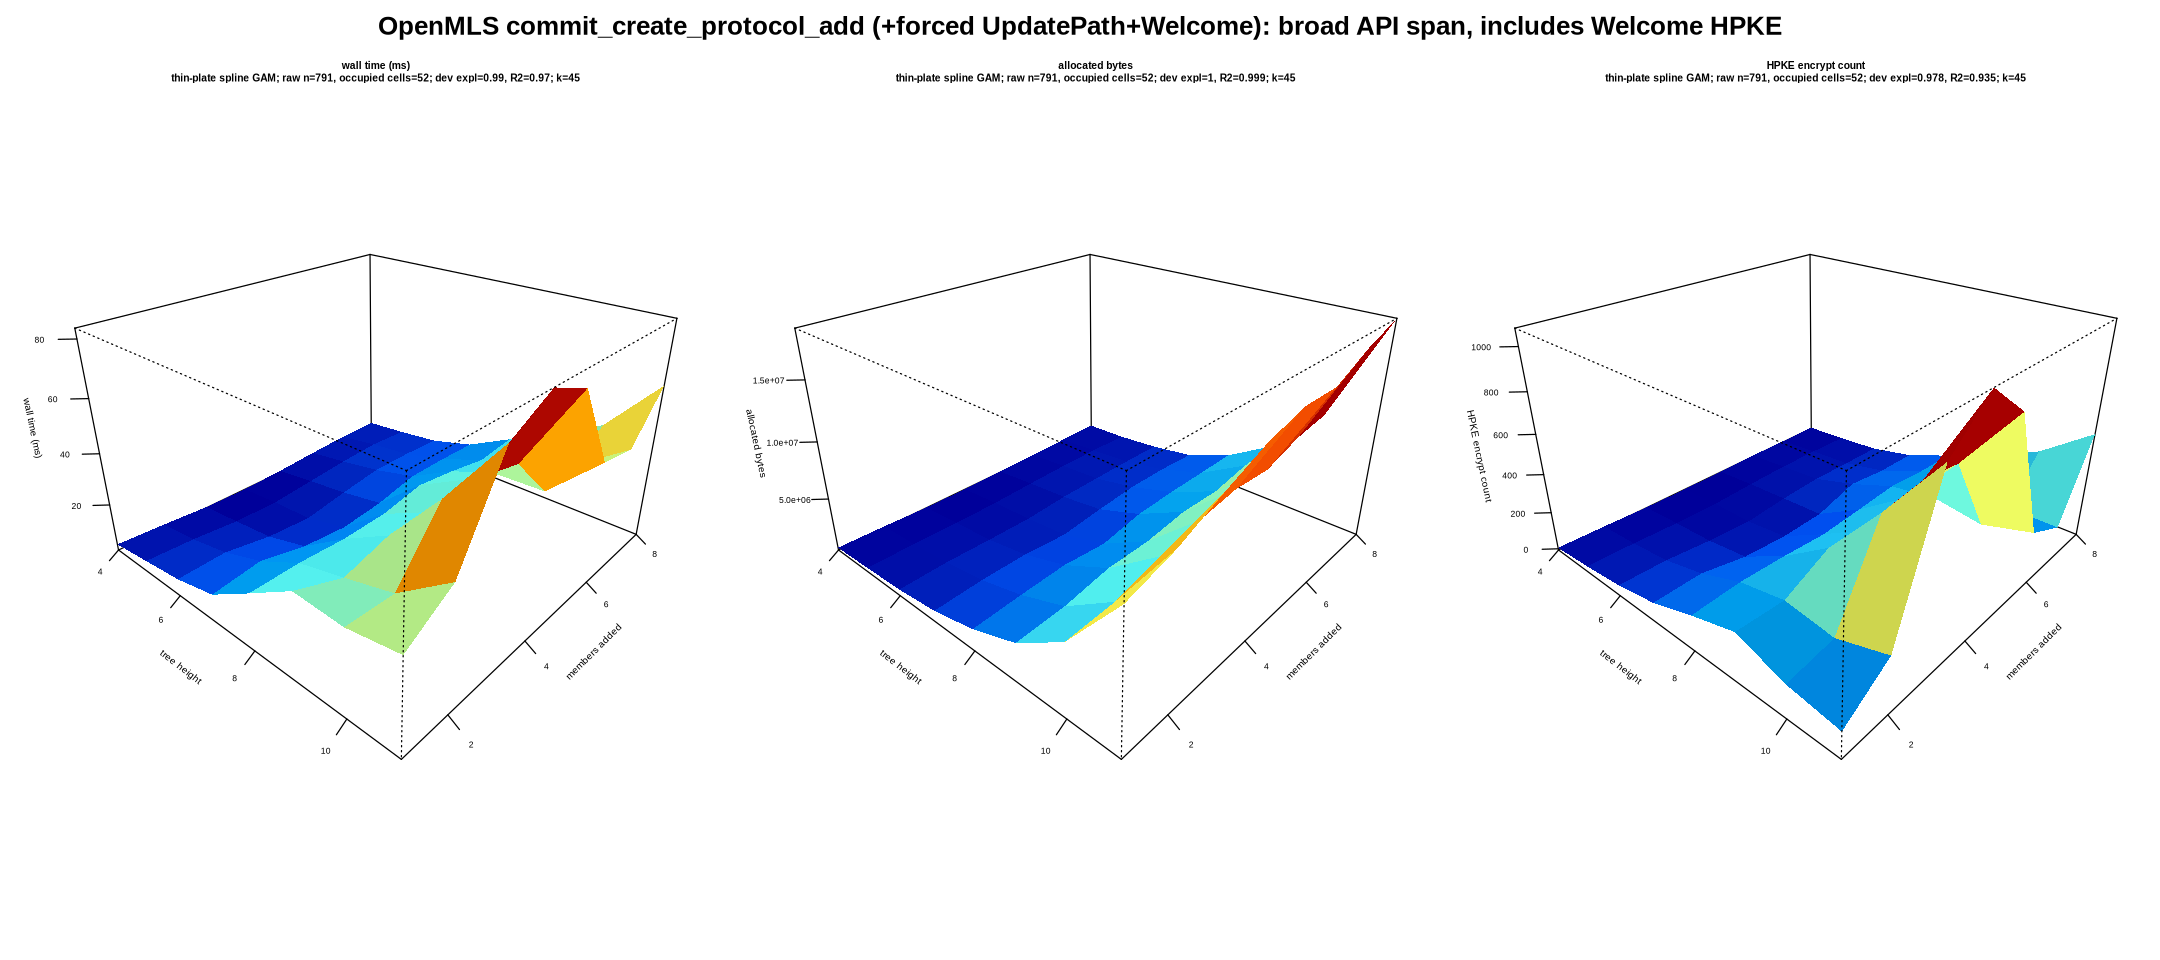

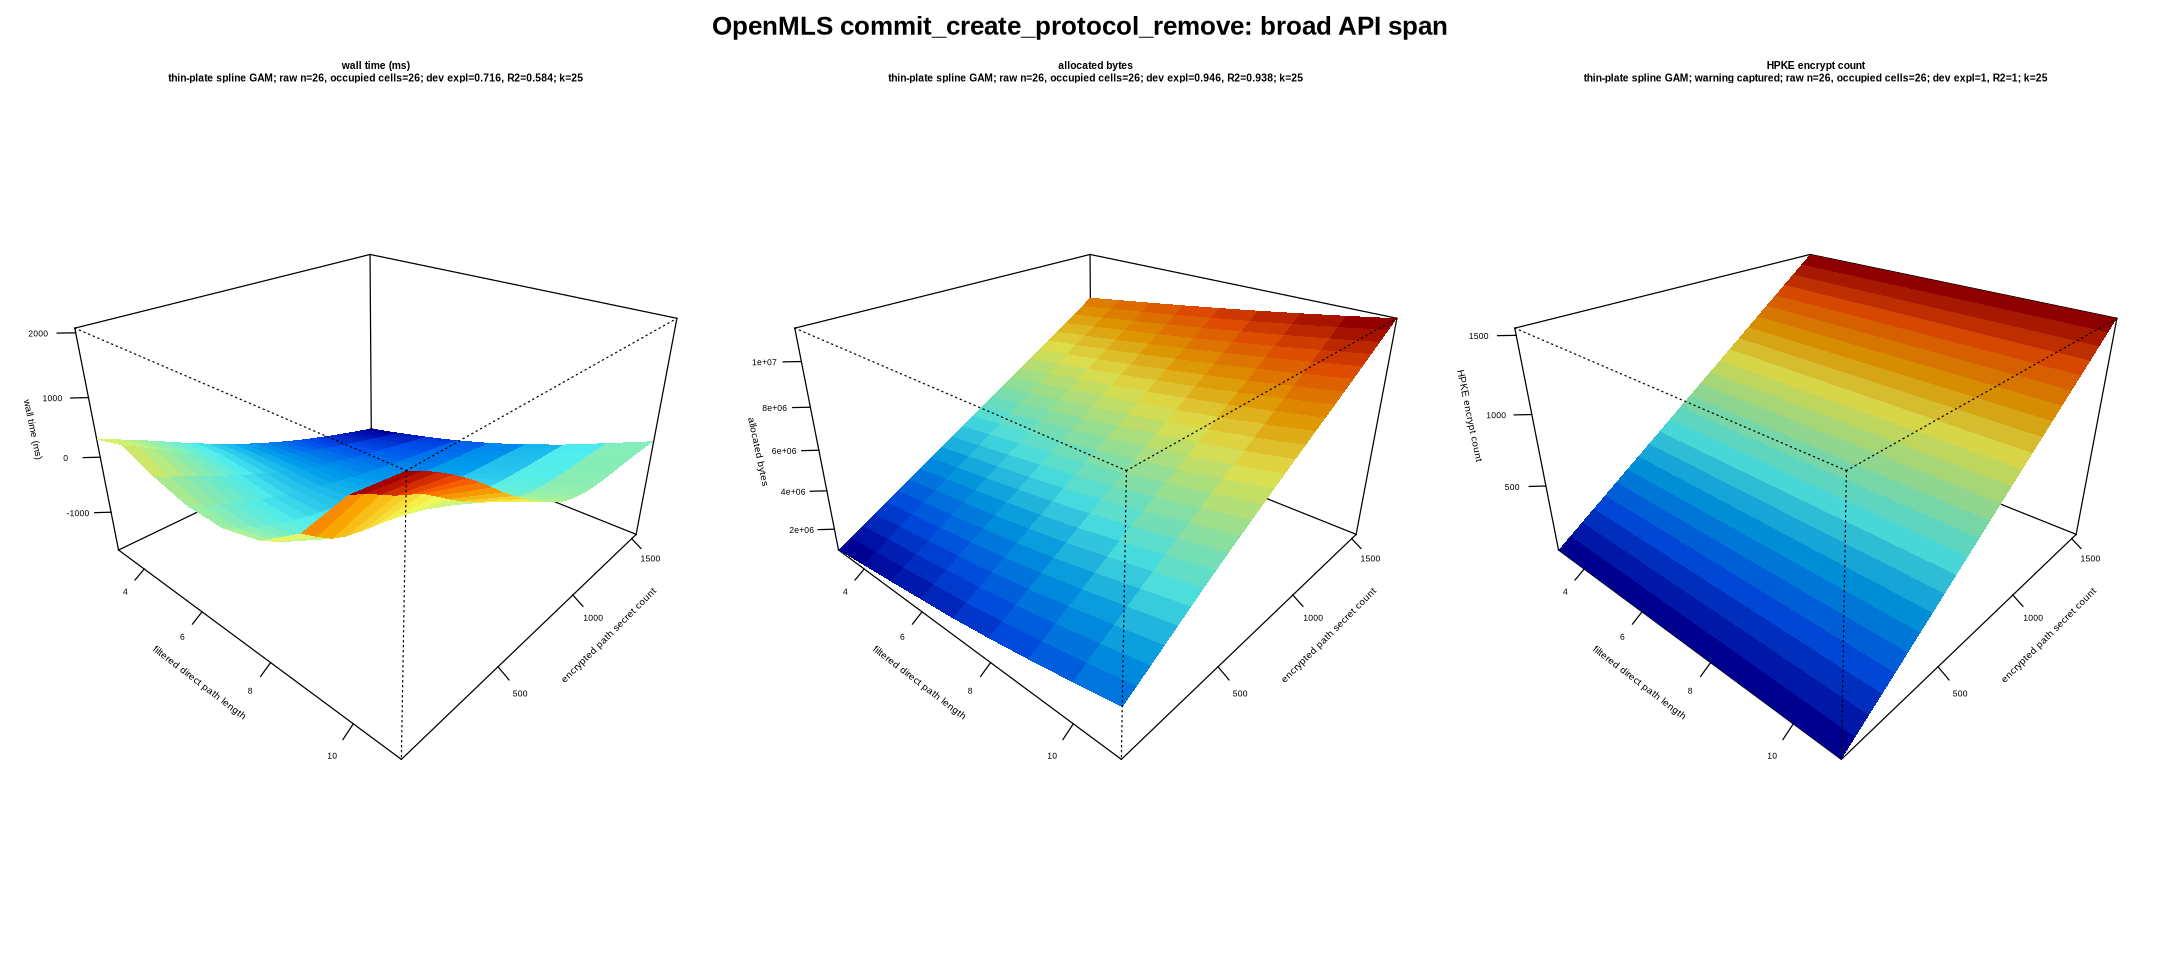

In [4]:
options(repr.plot.width = 18, repr.plot.height = 8)
plot_openmls_commit_update_api(openmls_v4_df)
plot_openmls_commit_add_api(openmls_v4_df)
plot_openmls_commit_remove_api(openmls_v4_df)


## Welcome creation

The current data shows recipient-count-driven Welcome size. In this run, `ratchet_tree_included` is false for all Welcome rows, so these plots do not yet represent an embedded ratchet-tree Welcome payload.


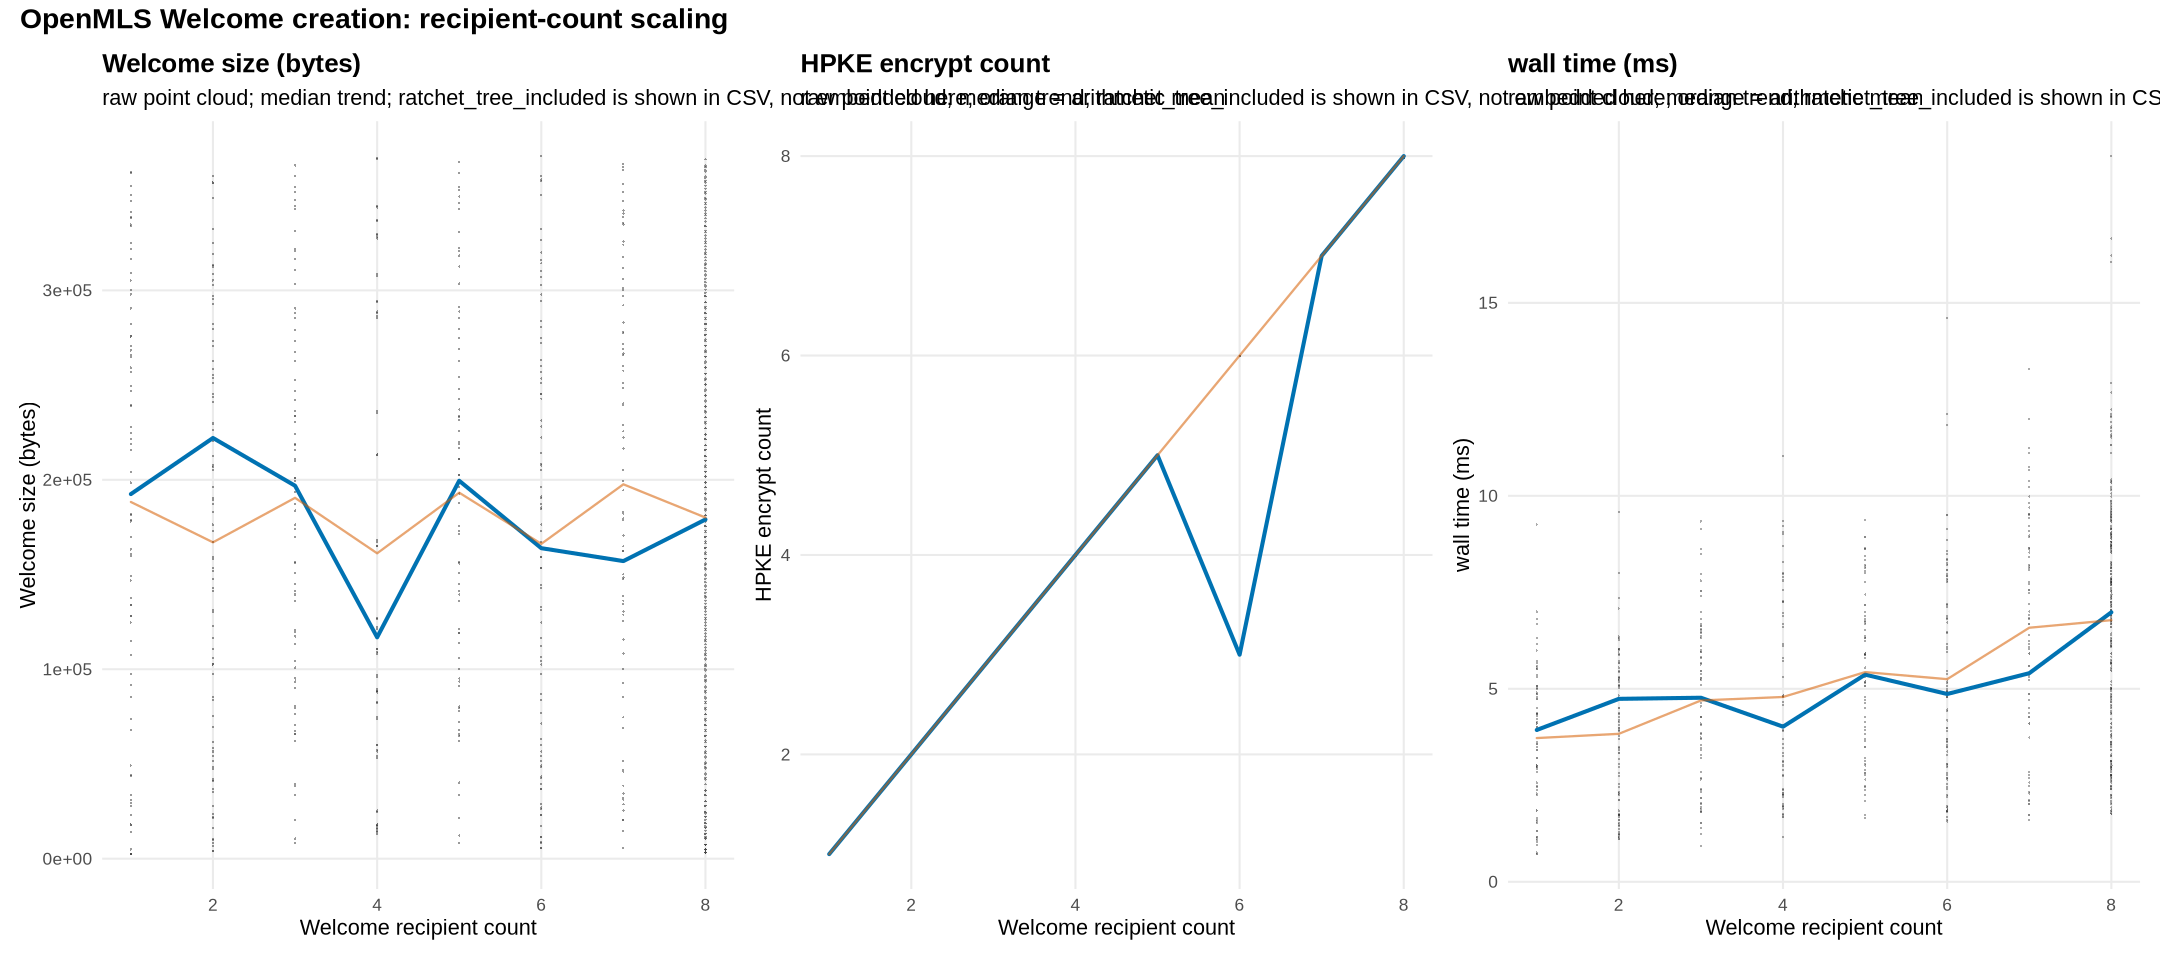

In [5]:
options(repr.plot.width = 18, repr.plot.height = 8)
plot_openmls_welcome(openmls_v4_df)


## Join from Welcome

Join is still a broad OpenMLS API span. Interpret it as full join implementation cost, currently best explained by ratchet-tree bytes and validation/tree-hash work rather than a pure HPKE decrypt span.


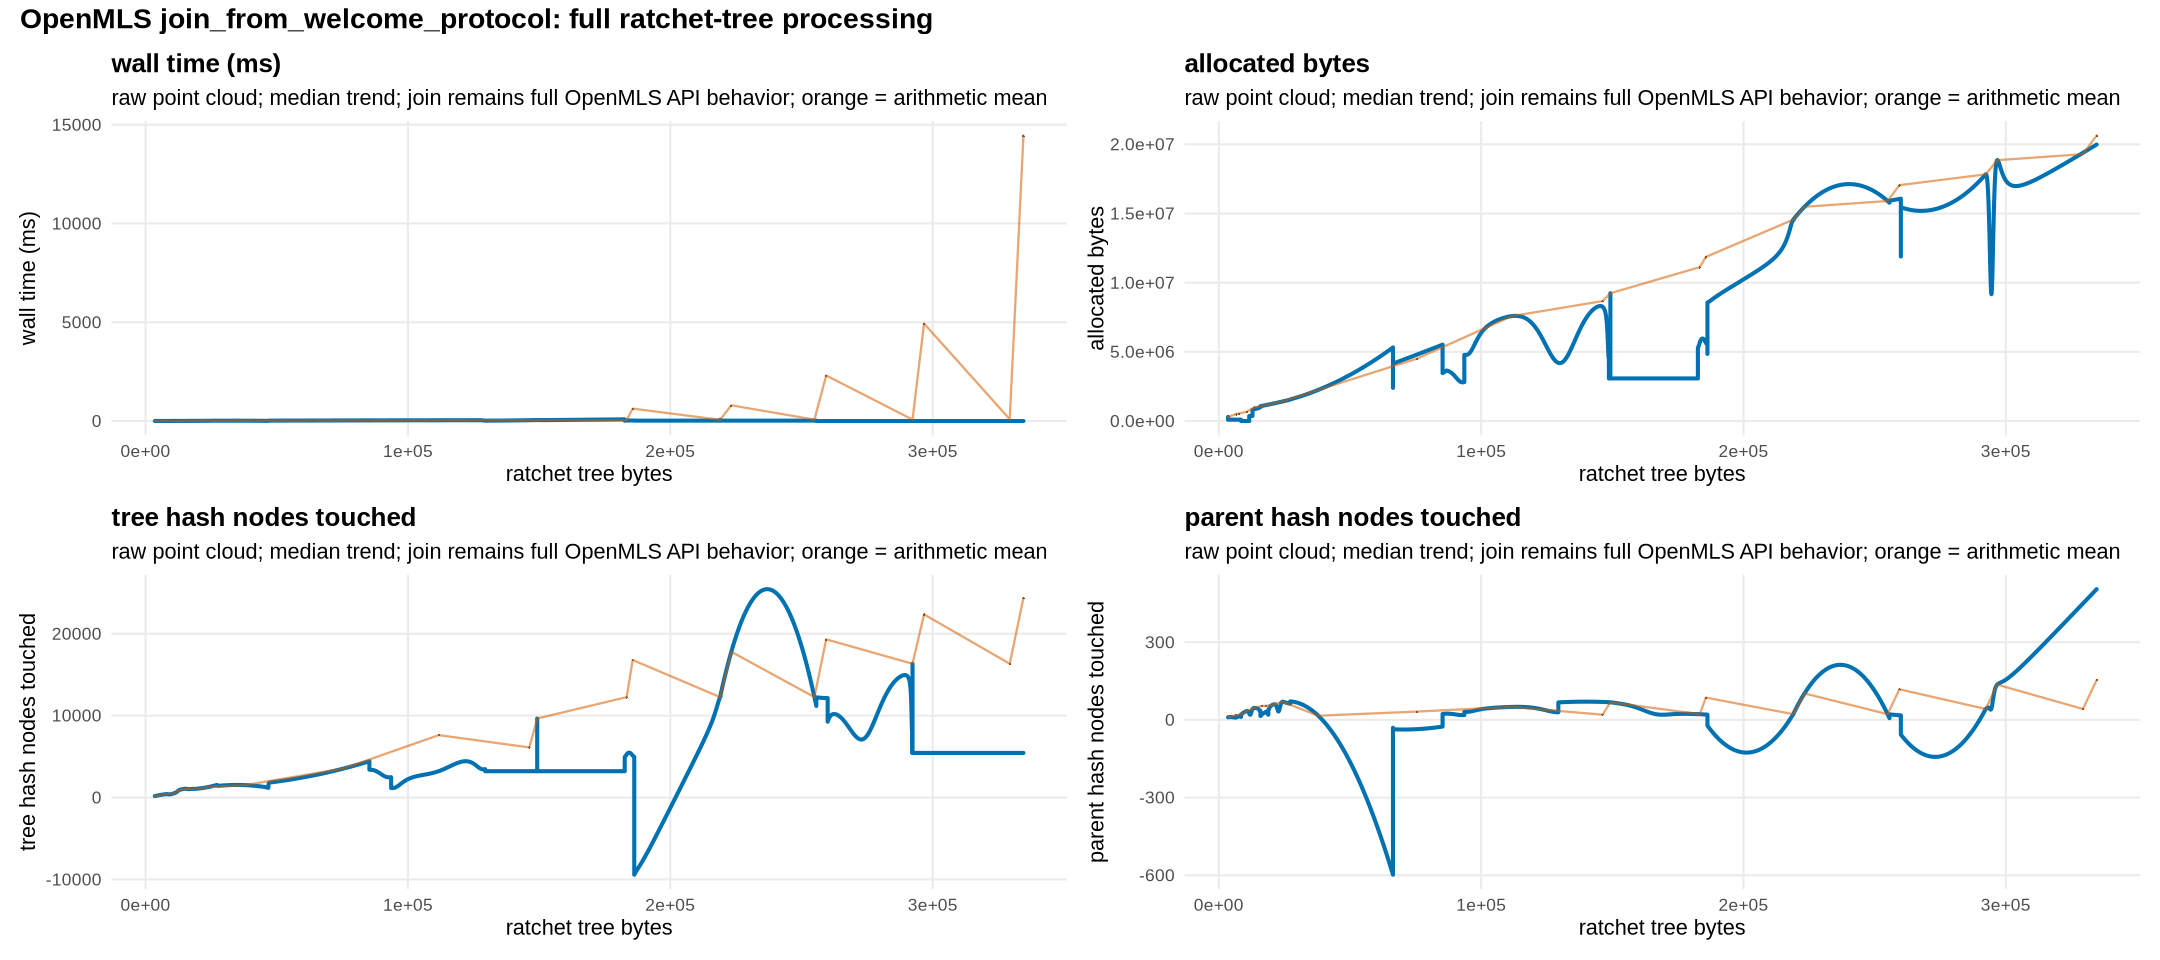

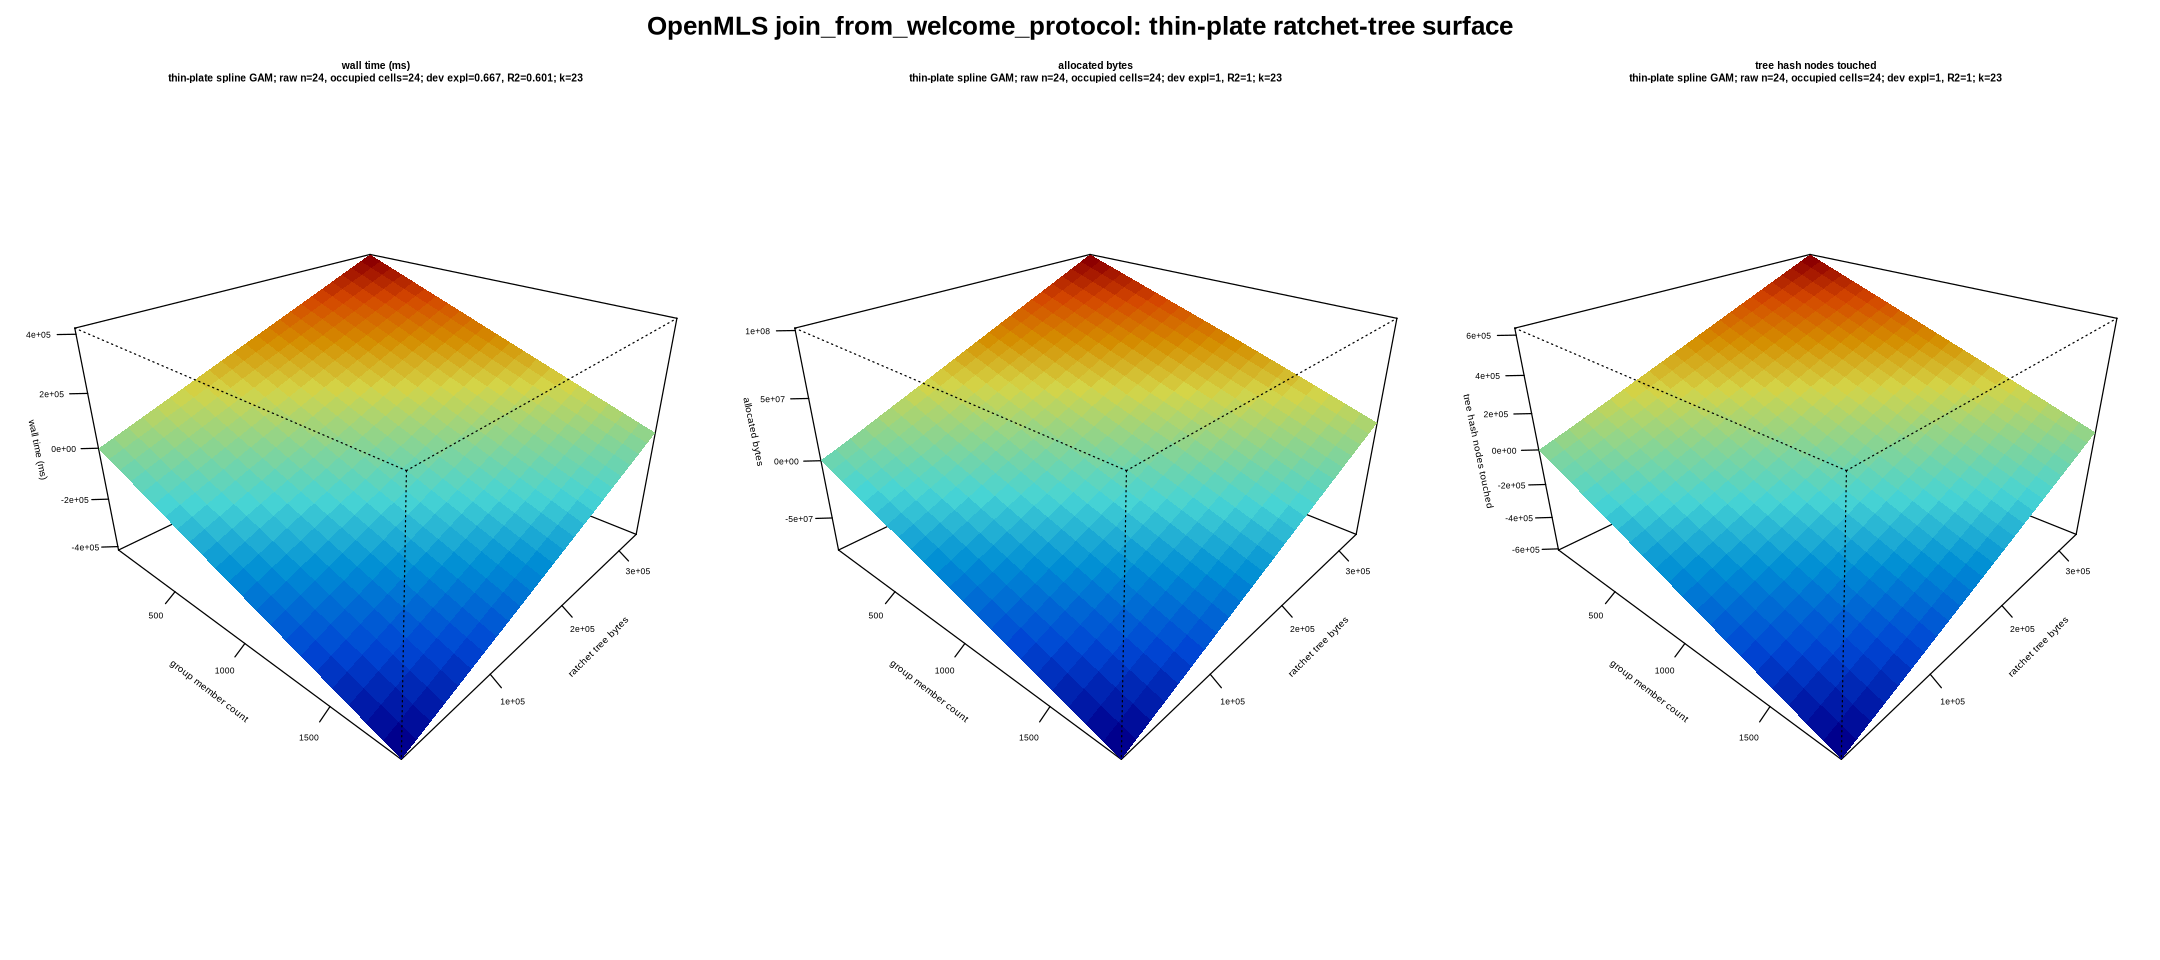

In [6]:
options(repr.plot.width = 18, repr.plot.height = 8)
plot_openmls_join_from_welcome(openmls_v4_df)


## Application messages

These plots are diagnostic only. The current rows still lack sender generation, generation gap, first-message flags, padding, and secret-tree derivation counters.


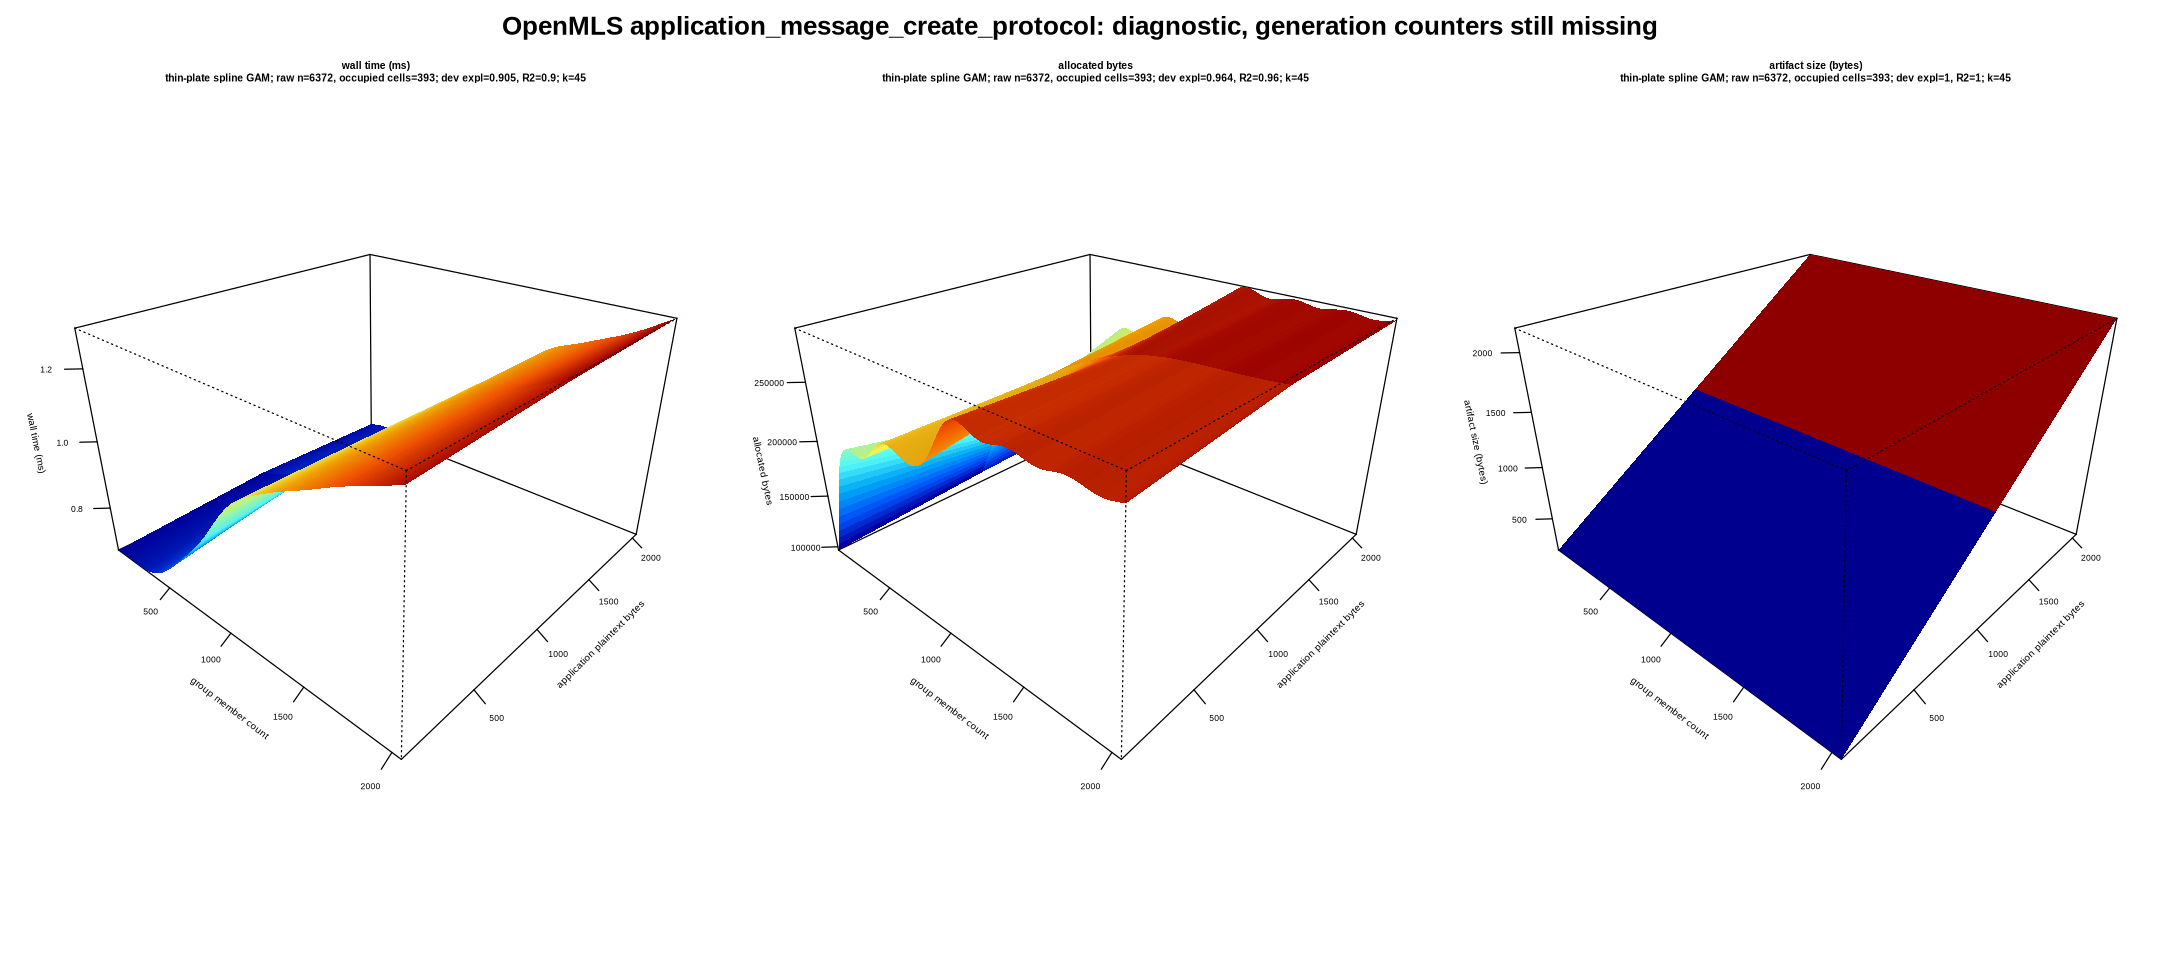

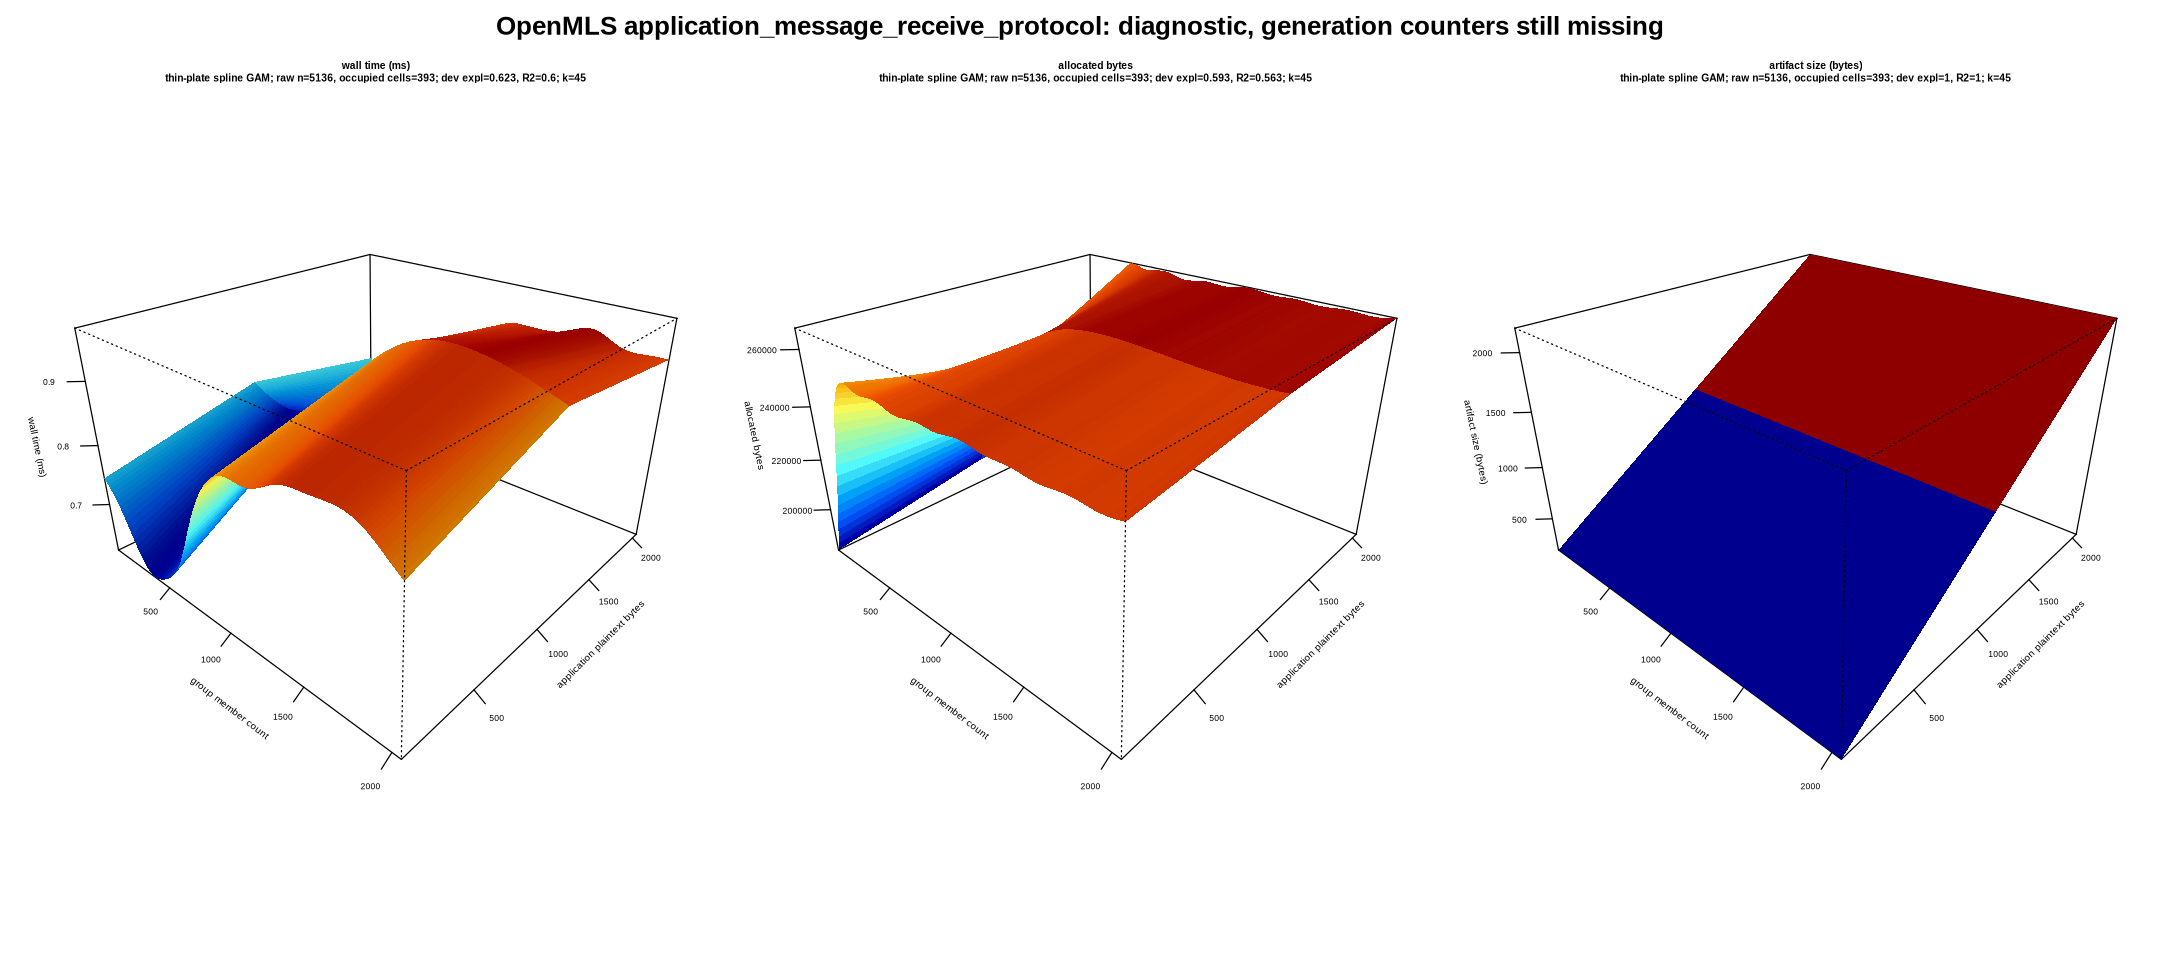

In [7]:
options(repr.plot.width = 18, repr.plot.height = 8)
plot_openmls_application_message_create(openmls_v4_df)
plot_openmls_application_message_receive(openmls_v4_df)


## Resource diagnostics

CPU and corrected L1D ratios are useful systems diagnostics, but they should not be used as direct evidence for RFC-level complexity.


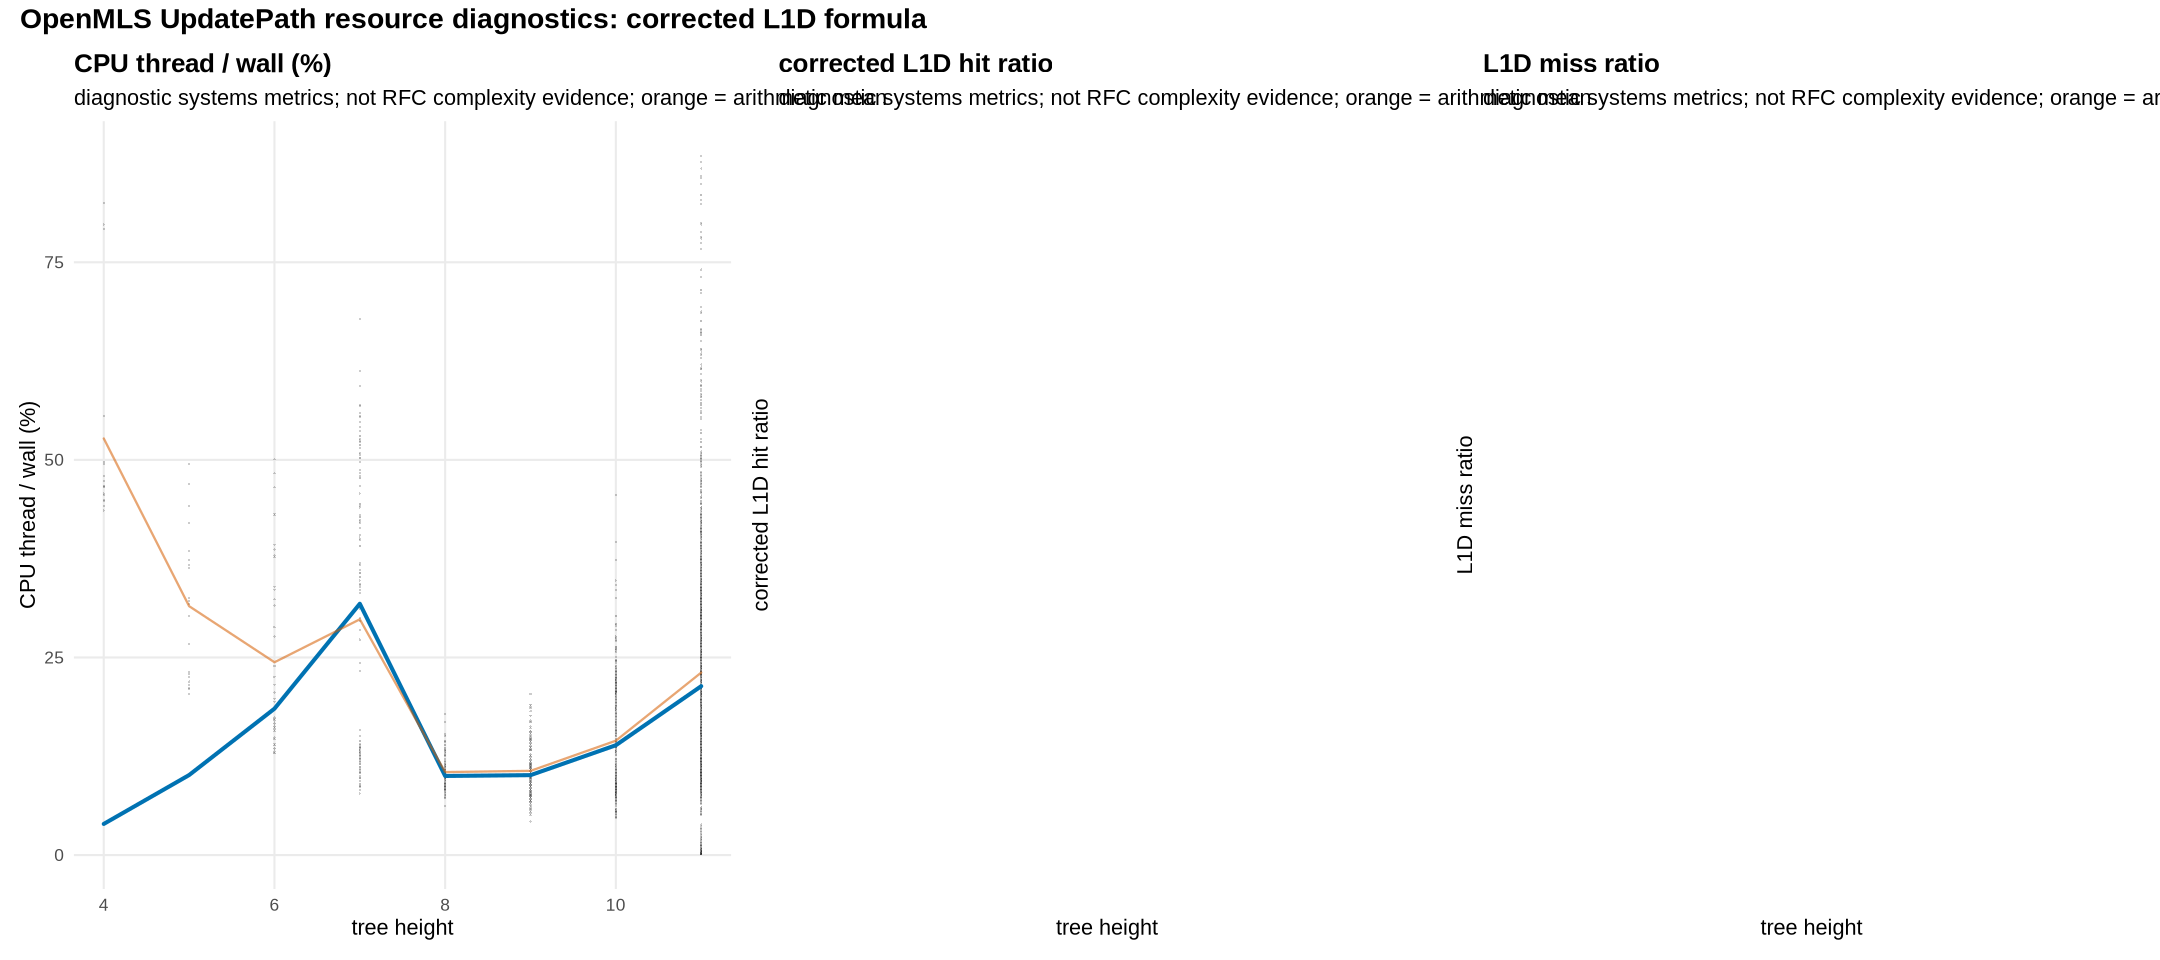

In [8]:
options(repr.plot.width = 18, repr.plot.height = 8)
plot_openmls_resource_diagnostics(openmls_v4_df)


## Export all v4 plots

Uncomment the code below to write the current v4 plot set to `OpenMLS_containerized/benchmark_output/.analysis_cache_v4/plots` unless `OPENMLS_V4_CACHE_DIR` overrides the cache directory.


In [9]:
# export_all_openmls_v4_plots(openmls_v4_df)
